# 03 · Descriptive EDA — the shape of the problem
### The Outliers · Mumbai Rent Radar

Before modelling anything, we establish **what the data looks like**: how rent is
distributed, how it moves with the obvious drivers, and where the city's money sits.
Following the project's rule, we **ask SQL first**, then bring the answers into Python
to see them.

**Input:** `data/processed/listings_imputed.csv` + `sql/rent.db`

In [3]:
import sys, sqlite3, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import squarify
from matplotlib.ticker import FuncFormatter
import style
warnings.filterwarnings("ignore")
style.setup()

df = pd.read_csv("../data/processed/listings_imputed.csv")
att = pd.read_csv("../data/processed/locality_attributes.csv")
df = df.merge(att[["locality_name", "zone"]], on="locality_name", how="left")
df["zone"] = df["zone"].fillna("unknown")
df["rent_per_sqft"] = df["rent"] / df["size"]
print("Listings:", len(df), "| median rent ₹{:,.0f}".format(df.rent.median()))

Listings: 5000 | median rent ₹55,000


## 1 · Ask SQL first
Two questions answered entirely in the database, before any Python plotting:
*how does rent climb with BHK*, and *which localities are the most expensive.*

In [4]:
con = sqlite3.connect("../sql/rent.db")
q_bhk = pd.read_sql_query("""
    SELECT bhk, COUNT(*) AS n, ROUND(AVG(rent)) AS avg_rent, ROUND(MIN(rent)) AS min_rent, ROUND(MAX(rent)) AS max_rent
    FROM listings WHERE rent IS NOT NULL GROUP BY bhk ORDER BY bhk;""", con)
q_top = pd.read_sql_query("""
    SELECT locality_name, COUNT(*) AS n, ROUND(AVG(rent)) AS avg_rent
    FROM listings WHERE rent IS NOT NULL GROUP BY locality_name
    HAVING COUNT(*) >= 10 ORDER BY avg_rent DESC LIMIT 8;""", con)
con.close()
print("Rent by BHK (SQL):\n", q_bhk.to_string(index=False))
print("\nMost expensive localities (SQL):\n", q_top.to_string(index=False))

Rent by BHK (SQL):
  bhk    n  avg_rent  min_rent  max_rent
   1 1513   30545.0    4500.0  130000.0
   2 1837   61912.0    5000.0  735000.0
   3 1194  127755.0   15000.0 1600000.0
   4  365  278789.0   45000.0 1528000.0
   5   89  510719.0   62500.0 6520000.0
   6    2  627000.0  461500.0  792500.0

Most expensive localities (SQL):
     locality_name  n  avg_rent
Sakinaka Junction 45  217011.0
      Turner Road 14  185000.0
          Mazgaon 19  184526.0
        Khar West 20  180425.0
   Santacruz West 24  174792.0
 Park Site Colony 11  166545.0
  Dadar TT Circle 20  156400.0
      JVPD Scheme 11  155318.0


## 2 · How is rent distributed?
The single most important picture. Rent is **heavily right-skewed** — most flats are
affordable, a few command enormous prices. That shape decides how we model.

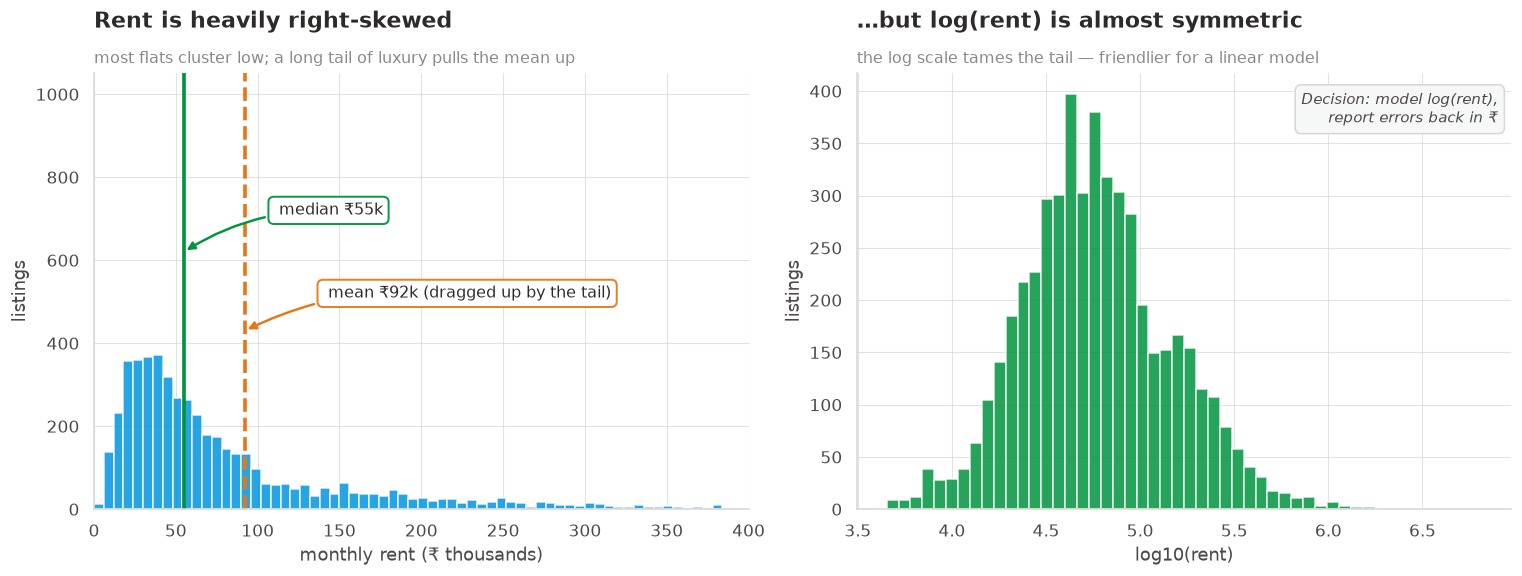

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ax = axes[0]
ax.hist(df["rent"] / 1000, bins=np.arange(0, 402, 6), color=style.BLUE, alpha=0.85, edgecolor="white")
ax.axvline(df.rent.median() / 1000, color=style.GREEN, lw=2.4)
ax.axvline(df.rent.mean() / 1000, color=style.ORANGE, lw=2.4, ls="--")
ymax = 1050
style.callout(ax, (df.rent.median() / 1000, 620), f" median ₹{df.rent.median()/1000:.0f}k",
              xytext=(110, 720), color=style.GREEN)
style.callout(ax, (df.rent.mean() / 1000, 430), f" mean ₹{df.rent.mean()/1000:.0f}k (dragged up by the tail)",
              xytext=(140, 520), color=style.ORANGE)
ax.set_xlim(0, 400); ax.set_ylim(0, ymax)
ax.set_xlabel("monthly rent (₹ thousands)"); ax.set_ylabel("listings")
style.title(ax, "Rent is heavily right-skewed", "most flats cluster low; a long tail of luxury pulls the mean up")

ax = axes[1]
logr = np.log10(df["rent"])
ax.hist(logr, bins=50, color=style.GREEN, alpha=0.85, edgecolor="white")
ax.set_xlabel("log10(rent)"); ax.set_ylabel("listings")
style.title(ax, "…but log(rent) is almost symmetric", "the log scale tames the tail — friendlier for a linear model")
style.note(ax, "Decision: model log(rent),\nreport errors back in ₹", where="upper right")
fig.tight_layout(); style.save(fig, "03_rent_distribution"); plt.show()

**Insight:** the mean rent sits well above the median — the classic signature of a
right-skewed price. **Decision:** the model will learn **log(rent)** and we translate
errors back into rupees, so a ₹10k miss on a ₹30k flat is not treated the same as on a ₹3L flat.

## 3 · Rent climbs with BHK — but the spread explodes
A violin shows both the typical rent and how *uncertain* it gets for bigger homes.

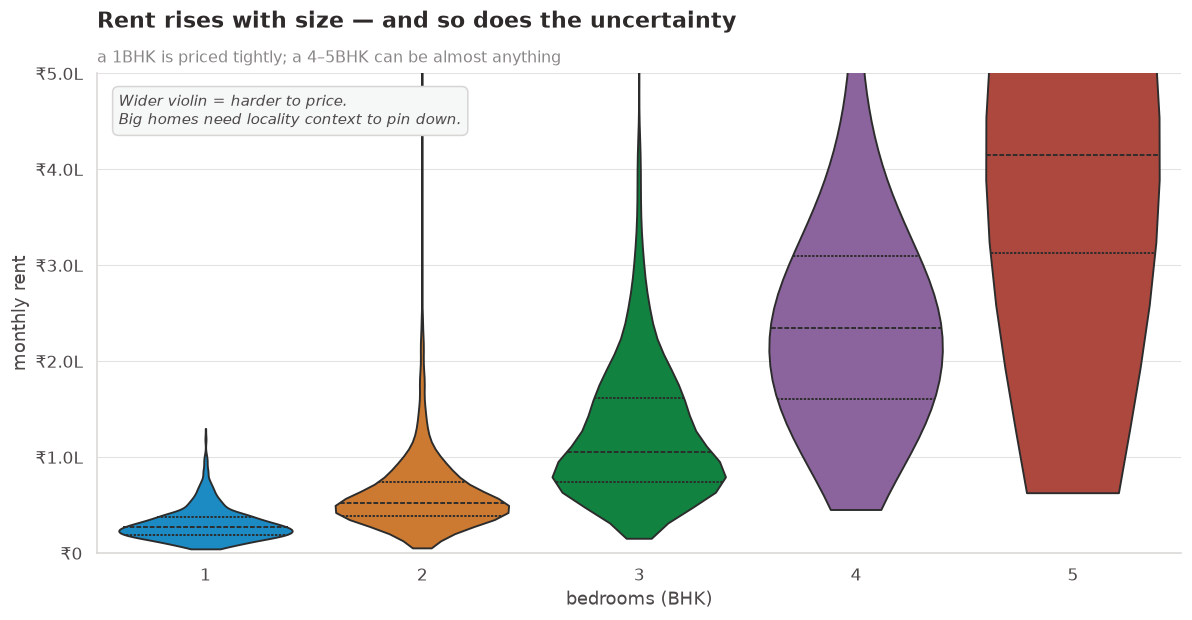

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.8))
import seaborn as sns
order = sorted(df["bhk"].unique())
sns.violinplot(data=df[df.bhk <= 5], x="bhk", y="rent", ax=ax, palette=style.CATEGORICAL, cut=0, inner="quartile")
ax.set_ylim(0, 500000)
ax.yaxis.set_major_formatter(FuncFormatter(style.rupee))
ax.set_xlabel("bedrooms (BHK)"); ax.set_ylabel("monthly rent")
style.title(ax, "Rent rises with size — and so does the uncertainty",
            "a 1BHK is priced tightly; a 4–5BHK can be almost anything")
style.note(ax, "Wider violin = harder to price.\nBig homes need locality context to pin down.", where="upper left")
fig.tight_layout(); style.save(fig, "03_rent_by_bhk"); plt.show()

**Insight:** each extra bedroom roughly doubles rent, but the violins fan out — a 4BHK
ranges from ₹1L to ₹5L. **Decision:** BHK alone is not enough; locality + size must help
explain the spread (the job of feature engineering).

## 4 · Where does the city's rental supply sit?
A treemap: each block is a zone, sized by number of listings. Quick sense of the market.

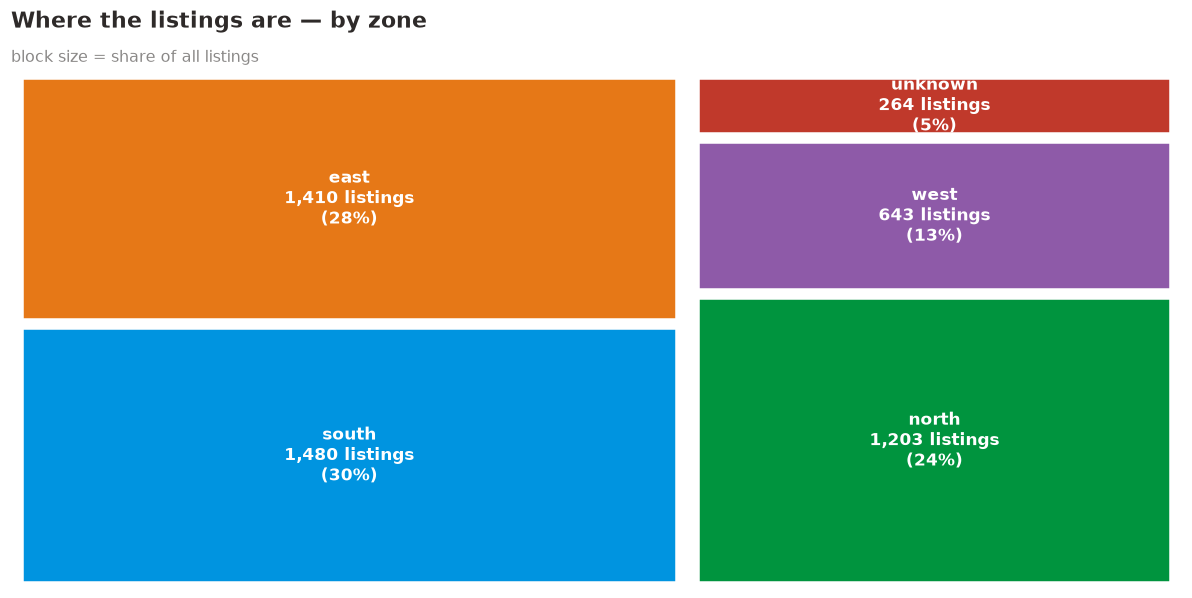

In [7]:
zc = df["zone"].value_counts()
fig, ax = plt.subplots(figsize=(11, 5.6))
cmap = {z: c for z, c in zip(zc.index, style.CATEGORICAL)}
squarify.plot(sizes=zc.values,
              label=[f"{z}\n{n:,} listings\n({n/len(df)*100:.0f}%)" for z, n in zc.items()],
              color=[cmap[z] for z in zc.index], ax=ax, pad=2,
              text_kwargs={"color": "white", "fontsize": 11, "fontweight": "bold"})
ax.axis("off")
style.title(ax, "Where the listings are — by zone", "block size = share of all listings")
fig.tight_layout(); style.save(fig, "03_zone_treemap"); plt.show()

## 5 · Value for money: rent per square foot by zone
Rent per sqft strips out flat size, exposing which *areas* are genuinely dear.

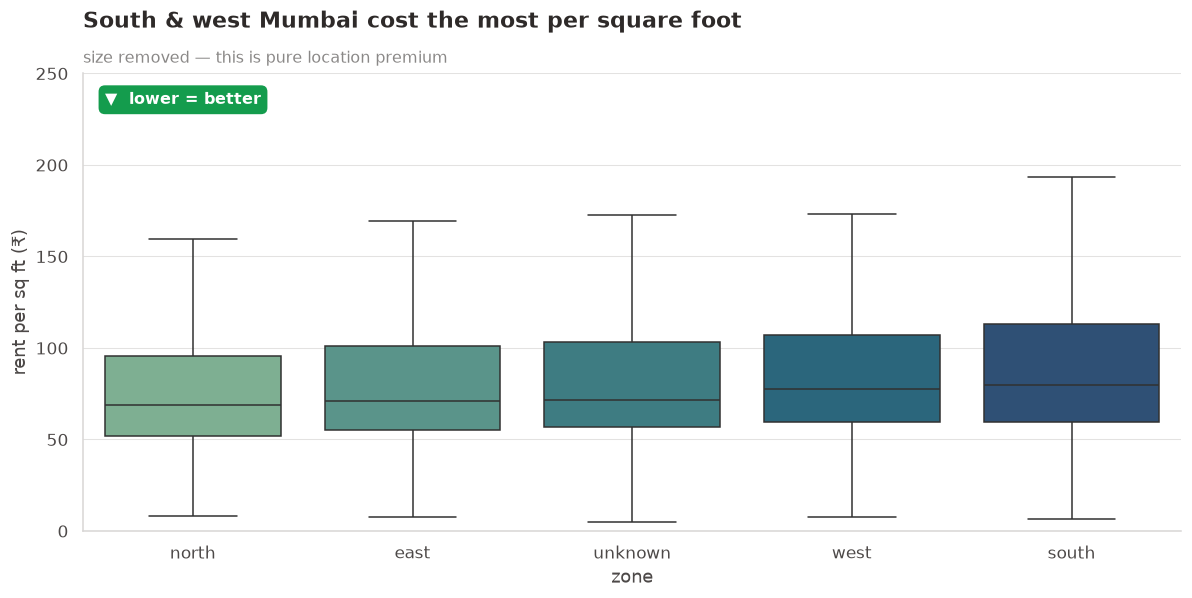

In [8]:
zorder = df.groupby("zone")["rent_per_sqft"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 5.6))
sns.boxplot(data=df, x="zone", y="rent_per_sqft", order=zorder, ax=ax,
            palette="crest", showfliers=False)
ax.set_ylim(0, 250); ax.set_xlabel("zone"); ax.set_ylabel("rent per sq ft (₹)")
style.title(ax, "South & west Mumbai cost the most per square foot",
            "size removed — this is pure location premium")
style.direction_badge(ax, "lower", "upper left")
fig.tight_layout(); style.save(fig, "03_rent_per_sqft_zone"); plt.show()

**Insight:** per-sqft rent orders the zones cleanly (south/west dearest). **Decision:**
encode zone and locality-level price signals as features.

## 6 · A price map: median rent by BHK × zone
One heatmap answers "what does an *N*-BHK cost in zone *Z*?" — the memo's core lookup.

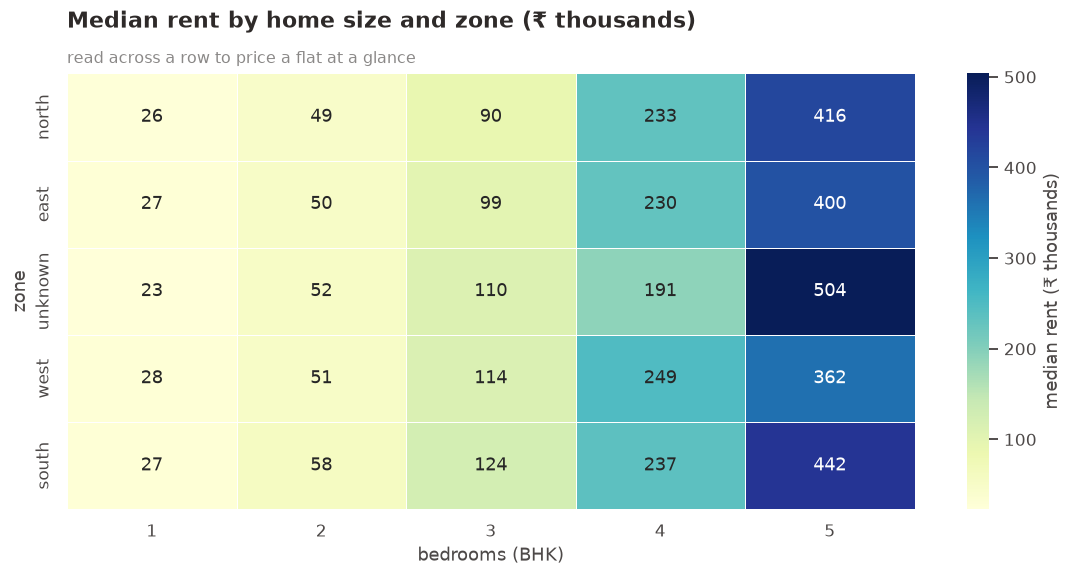

In [9]:
piv = df[df.bhk <= 5].pivot_table(index="zone", columns="bhk", values="rent", aggfunc="median")
piv = piv.reindex(zorder)
fig, ax = plt.subplots(figsize=(10.5, 5.4))
sns.heatmap(piv / 1000, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "median rent (₹ thousands)"}, linewidths=.5, linecolor="white")
ax.set_xlabel("bedrooms (BHK)"); ax.set_ylabel("zone")
style.title(ax, "Median rent by home size and zone (₹ thousands)",
            "read across a row to price a flat at a glance")
fig.tight_layout(); style.save(fig, "03_heatmap_bhk_zone"); plt.show()

## 7 · Ridgeline: the full rent distribution for each home size
Stacked densities make the *overlap* between sizes obvious — a big 2BHK can out-price a small 3BHK.

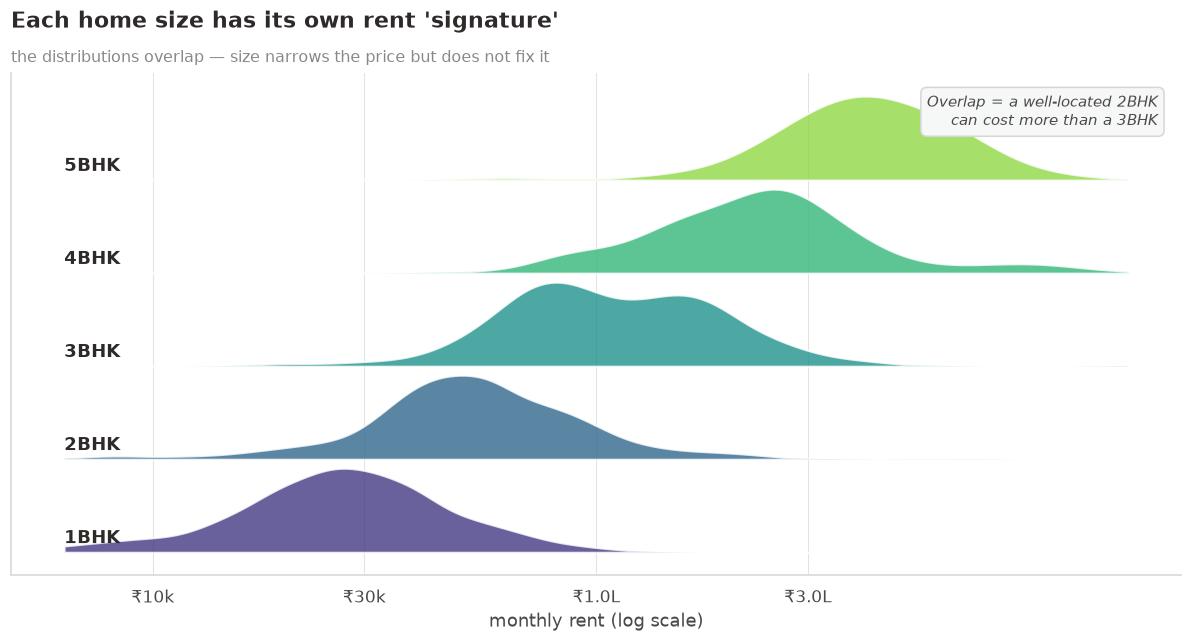

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
bhks = [1, 2, 3, 4, 5]
colors = sns.color_palette("viridis", len(bhks))
for i, b in enumerate(bhks):
    d = np.log10(df[df.bhk == b]["rent"].dropna())
    if len(d) < 5: continue
    xs = np.linspace(3.8, 6.2, 200)
    from scipy.stats import gaussian_kde
    dens = gaussian_kde(d)(xs); dens = dens / dens.max() * 0.9
    ax.fill_between(xs, i, i + dens, color=colors[i], alpha=0.8, lw=1.2, edgecolor="white")
    ax.text(3.8, i + 0.05, f"{b}BHK", fontweight="bold", color=style.INK, va="bottom")
ticks = [10000, 30000, 100000, 300000]
ax.set_xticks([np.log10(t) for t in ticks]); ax.set_xticklabels([style.rupee(t) for t in ticks])
ax.set_yticks([]); ax.set_xlabel("monthly rent (log scale)")
style.title(ax, "Each home size has its own rent 'signature'",
            "the distributions overlap — size narrows the price but does not fix it")
style.note(ax, "Overlap = a well-located 2BHK\ncan cost more than a 3BHK", where="upper right")
fig.tight_layout(); style.save(fig, "03_ridgeline_bhk"); plt.show()

## 8 · Summary statistics

In [11]:
summ = df[["rent", "size", "rent_per_sqft", "bhk", "bathroom", "floor_num"]].describe().T
summ = summ[["mean", "50%", "std", "min", "max"]].rename(columns={"50%": "median"})
print(summ.round(0).to_string())

                  mean   median       std     min        max
rent           92191.0  55000.0  146529.0  4500.0  6520000.0
size             941.0    758.0     692.0   150.0    15000.0
rent_per_sqft     85.0     74.0      61.0     5.0     2204.0
bhk                2.0      2.0       1.0     1.0        6.0
bathroom           2.0      2.0       1.0     1.0        7.0
floor_num         13.0     10.0      12.0    -2.0       76.0


### Takeaways from the descriptive picture
- Rent is **right-skewed** → we model **log(rent)**.
- Rent scales with **BHK and size**, but the spread widens → location must explain the rest.
- **South & west** zones carry the highest per-sqft premium.
- The BHK × zone heatmap already gives a usable first-cut "fair rent" lookup.

Next: *diagnostic* EDA — relationships, outliers, and one finding that looks impossible.